# Mini-Project: [Your Title Here]
**Intern:** [Your name]  
**Date started:** [Start date]  


---
## Context

You have already worked with this dataset in Module 4:

- **Data:** Fur ChIP-exo binding sites from Seo et al. 2014 — *Nature Communications* 5:4910 (GEO series **GSE54901** for the raw signal; the discrete binding sites come from the paper's **Supplementary Data** table you downloaded in Module 4)
- **Organism:** *E. coli* K-12 MG1655
- **Files in `data/reference/`:** Fur binding-site table (iron-replete sites, with `ChIP-exo Start`/`End`, `S/N ratio`, `Significance`, `Distance to TSS`), `NC_000913.fasta`, `ec_annotation_20100903_DHK_cSRNA_with_ortho.gff`, and the `fur_sites_for_meme.fasta` you generated.

Module 4 asked one specific question: *find the FUR binding motif.* This project asks you to go further and answer a question of your own choosing about the FUR regulon.


---
## Schedule Overview

| Day | Target milestone |
|-----|------------------|
| W5 D1 | Literature review done; candidate questions drafted |
| W5 D2 | Biological question finalized and instructor-approved |
| W5 D3 | Analysis plan written; pipeline scaffold annotated |
| W5 D4–5 | Pipeline running; first results visible |
| W6 D1–3 | All steps done; figures generated |
| W6 D4–5 | Report written; notebook submitted |

Run `/log` at the end of **every day**.


---
## Part 1 — What Else Is Known About FUR?
**Target: W5 Day 1**

You already know the Seo et al. 2014 dataset. Before proposing a question, find out what other groups have studied about the FUR regulon in *E. coli* — you want to ask something that either extends, challenges, or fills a gap in the existing literature.

Use Claude to help search and summarize. Key questions to answer:
- What genes are in the known FUR regulon?
- What is already known about FUR binding site position relative to promoters/TSS?
- Are there known differences between iron-replete and iron-depleted conditions?
- What aspects of FUR binding have *not* been studied with ChIP-exo?


**Literature summary** — 4–6 sentences covering what is known and what gaps exist:


> **Answer**
>
> [Your literature summary here]


> **W5 D1 checkpoint:**
> - [ ] At least 2 papers read beyond Seo et al. 2014
> - [ ] Gap or open question identified
> - [ ] `/log` run


---
## What Makes a Good Biological Question?

Before writing your question, use this checklist:

| Criterion | Ask yourself |
|-----------|-------------|
| **Answerable with available data** | Can you answer it using the files already in `data/reference/`? |
| **Not already answered** | Did Seo et al. 2014 or the papers you just read already answer this? |
| **Has a plausible mechanism** | If you found a pattern, would there be a biological reason for it? |
| **Specific and testable** | Can you describe the analysis in 2–3 steps and know what result would count as a "yes" or "no"? |

> **What the binding-site table gives you:** each Fur site has a `ChIP-exo Start`/`End`, a **`S/N ratio`** and a **`Significance (p-value)`** (these are the *signal-strength* / *score* fields — the `Peak` column is just an ID label like `P1`), a `Binding Condition` (`R` iron-replete / `S` iron-depleted / `R/S` both), and a `Distance to TSS` for many sites. Design your question around columns that actually exist.

### Examples of tractable questions with the FUR dataset

- *Do FUR binding sites closer to a TSS have a higher S/N ratio than sites far from a TSS?*
- *Are FUR sites that bind in both conditions (`R/S`) stronger (higher S/N ratio) than condition-specific ones?*
- *Does the GC content of FUR binding site sequences correlate with the site's S/N ratio?*
- *Which functional categories (metabolism, transport, stress response) of the target genes are most enriched among FUR binding sites?*

### Examples of questions to avoid

- *"What does FUR do?"* — already answered in the literature
- *"How many peaks are there?"* — answered in Module 4
- *"Is FUR important for iron regulation?"* — too broad, not answerable with this dataset alone

### Where to search for background

- **PubMed:** `pubmed.ncbi.nlm.nih.gov` — search `"FUR regulon E. coli"` or `"Fur binding E. coli iron"`
- **Google Scholar:** same search terms
- **The Seo et al. 2014 paper itself** — its Discussion section lists open questions

---


---
## Part 2 — Biological Question
**Target: W5 Day 2**

Propose **one specific, answerable** question about the FUR ChIP-exo dataset that goes beyond what Module 4 already showed you.

The question must be answerable using the files in `data/reference/`. If you need additional tools or datasets, use Claude Code to set them up.

Example questions at the right level of specificity:
- *"Do FUR binding sites with a higher S/N ratio show stronger motif matches than low-signal sites?"*
- *"Which genes in the lab annotation have a FUR binding site within their upstream region, and can you find a pattern in what those genes do?"*
- *"Do iron-replete–specific FUR sites (`R`) differ in location (regulatory vs internal) from sites bound in both conditions (`R/S`)?"*
- *"How does the GC content of FUR binding site sequences compare to randomly sampled genomic windows of the same length — and does GC content correlate with S/N ratio?"*

**Not acceptable:** *"What does FUR do?"* or *"How many peaks are there?"* (already answered in M4)


**My biological question:**


> **Answer**
>
> 가설: FUR가 직접 조절하는 오페론의 유전자 개수 분포는 *E. coli* K-12 전체 오페론 background distribution 과 비교하였을 때, 특정 크기 영역에 유의미하게 enrichment 되어 있을 것이다.
>
> - H0 (귀무): FUR 직접 조절 오페론 속 유전자 개수 분포는 *E. coli* K-12 전체 오페론의 크기 분포와 차이가 없다.(RegulonDB 참조)
> - H1 (대립): 두 분포 사이에 유의미한 차이가 있다. 즉, FUR 레귤론이 특정 오페론 크기에 enrichment 되어 있을 것이다.
>
> 가설 설정 배경: 논문 Fig. 3c 에서 FUR에 의해 직접 조절하는 유전자들은 무기이온 수송 및 대사 등 특정 COG (Cluster of Orthologous Groups) 범주에 집중되었음을 확인할 수 있었다. 
> 이처럼 FUR 레귤론이 기능적으로 특정 역할에 집중된 것을 알아본 것처럼 본 과제에서는  오페론 크기에 주목하여 그 크기 역시 한쪽으로 치우쳐 있는 것은 아닐지 가설을 설정하였다. 
>
> **사용할 DB: RegulonDB** 
>
> RegulonDB는 *E. coli* K-12의 전사조절(오페론 구조, 프로모터, TF 결합부위 등)에 대한 표준 큐레이션 DB로 UNAM(멕시코국립자치대학교) CCG에서 운영한다. Seo et al. 2014 논문(Supplementary Table 6, 7)에서 이 DB의 오페론 정보를 사용했다. 이번 분석에는 `OperonSet.tsv`(RegulonDB v12.0, Release 14.5, Salgado et al. 2023, *Nucleic Acids Research*, doi: 10.1093/nar/gkad1072)를 사용할 예정이다. 이 파일은 오페론별 `operonId`, `operonName`, `numberOfGenes`(=`operon_size`), `operonGenes` 목록으로 구성되어 있다.
>
> **가설 검증 방법:**
> 1. 배경군 구축: RegulonDB `OperonSet.tsv`에서 *E. coli* K-12 전체 오페론의 속 유전자 개수에 대한 분포를 만든다. (이 DB의 'operonName'이 논문의 Supplementary xlsx의 `Transcription Unit` 이름과 거의 1:1로 일치하는 것을 확인했다.
>
> 2. FUR군 구축: `ncomms5910_supp_data1.xlsx`의 `Transcription Unit`에서 고유한 TU만 중복 제거하여 추출한다 (같은 TU가 여러 ChIP-exo peak을 가질 수 있으므로, 중복 제거하지 않으면 그 오페론 크기 쪽으로 쏠리는 편향이 생긴다).
>
> 3. 각 고유 TU 이름을 RegulonDB `operonName`과 매칭하여 `numberOfGenes`를 가져온다 → FUR 레귤론군 분포 생성. 
> 매칭 실패 비율을 확인하고 (TU 이름이 다른 경우) 그 TU를 확인해 결과에 어떤 영향을 미치는지 검증한다.
>
> 4. 통계 검정: FUR군 vs 배경군의 `operon_size` 분포를 "Mann-Whitney U test" 로 비교한다. 논문 Supplementary Fig. 7 결합강도 그룹을 비교할 때 위의 검정을 사용했다. (본 통계검증 방법은 정규분포를 사용할 수 없는 한쪽으로 치우친 데이터를 파악할 때 유용하다.)
>
> 5. 두 그룹의 `operon_size` 히스토그램, Box plot 을 시각화한다.
>
> **판단 기준:** p<0.05이고 FUR 레귤론군의 평균, 중앙값 `operon_size`가 배경군과 유의미하게 다른 방향으로 벗어나면 귀무가설을 기각한다.
>
> **질문의 의의:** 논문에서 오페론 크기 관점의 enrichment는 다루지 않았다. 또한 *E.coli* 의 전사조절 DB인 RegulonDB 를 이용해 검증한다는 점에서 의의가 있다. 

In [ ]:
# OperonSet.tsv 파일 파싱 및 헤더 확인. 
from pathlib import Path
import pandas as pd

def find_repo_file(relative_path, start=None):
    start = Path(start or Path.cwd()).resolve()
    for directory in [start, *start.parents]:
        candidate = directory / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {relative_path!r} at or above {start}")

operon_path = find_repo_file("data/reference/OperonSet.tsv")

df = pd.read_csv(operon_path, sep='\t', skiprows=26)
df.columns = [c.split(')', 1)[-1].strip() for c in df.columns]

print(f"전체 오페론 개수: {len(df)}")
df.head(5)


전체 오페론 개수: 2605


,operonId,operonName,firstGeneLeftPos,lastGeneRightPos,strand,numberOfGenes,operonGenes,operonEvidence,confidenceLevel
0,RDBECOLIOPC00001,pheLA,2737599,2738905,forward,2,pheL|pheA,[EXP-IDA-TRANSCRIPT-LEN-DETERMINATION:S],S
1,RDBECOLIOPC00002,yejO,2286390,2290180,reverse,1,yejO,NaN,
2,RDBECOLIOPC00003,ybcLM,570893,572251,forward,2,ybcL|ybcM,[COMP-AINF:W],W
3,RDBECOLIOPC00004,yqfB,3043312,3043623,reverse,1,yqfB,[COMP-AINF:W],W
4,RDBECOLIOPC00005,atoDAEB,2323447,2327293,forward,4,atoD|atoA|atoE|atoB,NaN,


> **INSTRUCTOR CHECK-IN REQUIRED** before proceeding to Part 3.  
> Do not start the analysis plan until your question is approved.


---
## Part 3 — Analysis Plan
**Target: W5 Day 3**

Write your analysis plan **before** opening Claude Code. This is your own thinking.

Your plan must answer:
1. Which files in `data/reference/` will you use?
2. What steps will you run, in order?
3. What output do you expect at each step?
4. How will you decide if the result is biologically meaningful?


> **Answer**
>
> [Your analysis plan here — write this before asking Claude Code]
> 1. ncomms5910_supp_data1.xlsx, data/reference/OperonSet.tsv
> 2. 1) OperonSet 파싱·헤더 확인 → 2) xlsx TU 중복 제거(forward-fill, 결측치는 앞의 값으로 채운다) → 3) TU <-> operonName 매칭, unmapped 기록 → 4) Mann-Whitney U test → 5) 히스토그램, 박스플롯 
> 3. step 1 에서는 오페론 전체에 대한 테이블을 확인할 것이고 step 2 에서는 Fur 군 operon size 리스트와 unmapped 비율, 마지막으로 step 4 에서는 p-value 를 확인할 것이다. 
> 4. p<0.05 + 방향성으로 확인한다. 

**Pipeline scaffold** — use plan mode (Shift+Tab twice) to generate the pipeline.  
Review every proposed step. Annotate each command with your own understanding of what it does.


In [ ]:
# Step 1: RegulonDB OperonSet.tsv를 파싱해 전체 오페론의 유전자 개수 분포(배경군)를 만든다.


# Step 2: xlsx에서 FUR가 결합하는 Transcription Unit(TU) 목록을 병합-셀 처리 후 중복 제거해 추출한다.


# Step 3: 추출한 TU 이름을 RegulonDB operonName과 매칭해 오페론 크기를 가져오고, 매칭 실패 TU를 기록한다.


# Step 4: FUR군과 배경군의 operon_size 분포를 Mann-Whitney U test로 비교한다.


# Step 5: 두 그룹의 operon_size를 히스토그램·박스플롯으로 시각화한다.

> **W5 D3 checkpoint:**
> - [ ] Analysis plan written in your own words
> - [ ] Pipeline scaffold annotated (you can explain every command)
> - [ ] Instructor has approved your biological question
> - [ ] `/log` run


---
## Part 4 — Analysis Execution
**Target: W5 Days 4–5 and W6 Days 1–3**

Run your pipeline step by step. Add code cells as needed.  
When blocked: paste the error + command + relevant output into Claude Code and ask for diagnosis — then use `/debug`.

Track your progress:

| Step | Status |
|------|--------|
| [Step 1 name] | not started / in progress / done |
| [Step 2 name] | not started / in progress / done |
| [Step 3 name] | not started / in progress / done |



In [10]:
# Step 1
from pathlib import Path # 파일 경로를 다루기 위한 표준 라이브러리.
import re # 정규표현식(regex) 라이브러리
import pandas as pd # 판다스
import matplotlib.pyplot as plt # 그래프 라이브러리
from scipy.stats import mannwhitneyu # 통계 라이브러리

def find_repo_file(relative_path, start=None):
    # 커널의 작업 디렉토리가 어디든 상관없이 현재 위치에서 위로 올라가며 파일을 찾는다.
    start = Path(start or Path.cwd()).resolve()
    for directory in [start, *start.parents]:
        candidate = directory / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {relative_path!r} at or above {start}")

> **Answer**
>
> *What did this step produce? Any issues?*
> 이 단계는 본격적으로 연구에 들어서기 앞선 준비 단계이다. 필요한 라이브러리를 import 한다. 특히 마지막에 그래프로 시각화할 것이기에 matplotlib을 불러온다. 그리고 find_repo_file 함수를 사용해 현재 위치와 상관없이 파일을 찾는 기능을 만든다. 


In [11]:
# Step 2
# 배경군 — RegulonDB 전체 오페론 파싱
operon_path = find_repo_file("data/reference/OperonSet.tsv") # find_repo_file 함수로 파일 경로 찾기. 
bg = pd.read_csv(operon_path, sep="\t", skiprows=26) # 탭으로 구분된 파일 읽기, 위쪽 26줄은 라이선스, 인용정보 주석이라 건너뜀.
bg.columns = [c.split(")", 1)[-1].strip() for c in bg.columns] # 컬럼명이 1)operonId 처럼 되어있으므로 ")" 기준으로 분리하여 정제 후 자르기.
print(f"[Step 1] 배경군 전체 오페론 개수: {len(bg)}") # 전체 오페론(배경군) 개수 출력. 

[Step 1] 배경군 전체 오페론 개수: 2605


> **Answer**
>
> *What did this step produce? Any issues?*
>
> 여기서 OperonSet.tsv 파일은 RegulonDB에서 받은 E.coli K-12의 전체 오페론 목록이다. 탭으로 구분된 표 형식이고 위쪽 26줄은 라이선스, 출처, 컬럼 설명 주석이므로 건너뛴다. 또한 컴퓨터가 읽기 편하게 1)operonId 2)operonName 등으로 적힌 컬럼명을 operonId, operonName등으로 바꾸는 작업을 해준다. 
>
> DB 내 전체 오페론 개수는 2605개인것을 확인할 수 있다. 

In [12]:
# Step 3
# FUR군 — xlsx에서 고유 TU 추출 (중복 제거)
# 엑셀에서 같은 TU를 가지는 피크를 하나의 셀로 합치고 나머지 셀은 ffill()로 위 값을 복사해서 채워줌.
xlsx_path = find_repo_file("data/reference/ncomms5910_supp_data1.xlsx") # 논문 데이터 파일 탐색.
fur = pd.read_excel(xlsx_path, sheet_name="Supplementary Data 1", header=1) # 엑셀 시트에서 두 번째 줄을 컬럼 헤더로 읽어옴
fur[["Binding Sites", "Transcription Unit"]] = fur[["Binding Sites", "Transcription Unit"]].ffill() # NaN 값을 직전 값으로 채움
fur_unique_tu = fur["Transcription Unit"].dropna().unique() # Transcription Unit 컬럼에서 결측치를 제거하고 중복 없는 고유 TU 목록 추출
print(f"[Step 2] FUR 결합 고유 TU 개수: {len(fur_unique_tu)}") # 추출된 고유 Fur 결합 TU 개수 출력. 

[Step 2] FUR 결합 고유 TU 개수: 119


> **Answer**
>
> *What did this step produce? Any issues?*
>
> 논문 supplementary 엑셀에서 FUR가 결합하는 고유한 Transcription Unit(TU) 이름 목록을 뽑아낸다. 이것은 총 119개인데, pd.read_excel 을 보면 엑셀 시트를 읽을 때, header=1로 두 번째 줄의 실제 컬럼 헤더를 읽는 것을 알 수 있다. 
>
> 또한 ffill()로 병합셀을 처리한다. 엑셀을 보면 하나의 오페론이 여러 peak에 걸쳐있는 것을 확인할 수 있다. 예를 들면, fhuACDB가 P3, P4, P5 세 peak와 매칭되어 있다. 따라서 이 행을 pandas로 읽어 가장 첫 행 빼고 나머지를 NaN으로 읽히고 ffill()으로 위의 값을 아래 NaN값들에 복사해서 채워주는 작업을 하였다. 
>
> 최종적으로 FUR 결합 고유 TU 개수가 119개인 것을 확인했다. 

In [13]:
# Step 4
# TU 와 RegulonDB operon 매칭 및 unmapped 기록 
name_to_size = bg.set_index("operonName")["numberOfGenes"].to_dict() # operonName 이 키, numberOfGenes 이 값인 딕셔너리 생성
gene_to_size = {} # 개별 유전자명과 오페론 크기를 매핑할 빈 딕셔너리. 
for _, row in bg.dropna(subset=["operonGenes"]).iterrows(): # operonGenes 행을 순회
    for gene in row["operonGenes"].split("|"): # "|" 로 구분된 유전자 목록을 분할
        gene_to_size[gene.strip()] = row["numberOfGenes"] # 공백을 제거한 개별 유전자명을 키로 오페론 크기를 매핑 딕셔너리에 저장

def lookup_operon_size(tu_name): # TU 이름을 바탕으로 오페론 크기를 조회하는 함수
    if tu_name in name_to_size: # TU 가 RegulonDB 오페론 이름과 일치하는지 확인
        return name_to_size[tu_name] # 일치 시 오페론 크기 반환
    for gene in re.split(r"[-/]", tu_name): # "-" 이나 "/" 로 TU 이름을 분할하여 개별 유전자 탐색
        if gene in gene_to_size: # 분할된 유전자가 유전자 매핑 딕셔너리에 존재하는지 확인
            return gene_to_size[gene] # 존재 시 매핑된 오페론 크기 반환
    return None # 없으면 None

tu_to_size = {tu: lookup_operon_size(tu) for tu in fur_unique_tu} # 모든 고유 Fur TU에 대해 오페론 크기를 찾아 딕셔너리로 저장
unmapped_tus = [tu for tu, size in tu_to_size.items() if size is None] # 매칭 실패(None) TU들만 추출하여 리스트 생성.
fur_sizes = [size for size in tu_to_size.values() if size is not None] # 매칭 성공한 Fur 군의 오페론 크기 수치들만 리스트로 추출
bg_sizes = bg["numberOfGenes"].tolist() # 배경군 전체 오페론의 유전자 수(numberOfGenes)를 리스트로 변환

unmapped_rate = len(unmapped_tus) / len(fur_unique_tu) # 전체 TU / 매칭 실패 TU 비 계산
print(f"[Step 3] 매칭 성공: {len(fur_sizes)}/{len(fur_unique_tu)} ({unmapped_rate:.1%} unmapped)")
print(f"[Step 3] unmapped TU 목록: {unmapped_tus}")

[Step 3] 매칭 성공: 101/119 (15.1% unmapped)
[Step 3] unmapped TU 목록: ['entCEBAH', 'sdhCDAB', 'efeUOB', 'ycgG', 'ymgI', 'gmr', 'yoaD', 'yebN', 'yebS', 'yfcUTSRQPO', 'ygaQ_2', 'yqjH', 'yhhK', 'insJK', 'qor', 'yjdQ', 'yjgI', 'yjhIH']


> **Answer**
>
> *What did this step produce? Any issues?*
>
> 두 개의 딕셔너리를 만든다:
> - name_to_size: operonName을 Key, numberOfGenes(오페론 크기)를 Value로 매핑
>
> - gene_to_size: operonGenes 문자열(예: "geneA|geneB")을 | 구분자로 분리하여, 각 개별 유전자명(geneA, geneB)을 Key, 해당 오페론의 numberOfGenes를 Value로 각각 저장
>
> name_to_size 딕셔너리는 오페론의 공식 이름이 Key이고, gene_to_size 딕셔너리는 개별 유전자의 이름이 Key이므로 총 1차, 2차로 탐색을 하여 매핑할 수 있게 한다. 
>
> 생물정보학에서 DB와 매칭 실패로 버려지는 데이터가 많을수록 통계적 유의성이 떨어지는데 유연한 매핑 로직을 구현하여 그것을 해결하고자 했다. 또한 매핑되지 않은 것들을 확인하여 데이터 공정의 투명성과 최종 결과에 미치는 영향을 파악해보았다. 

In [14]:
# step 5
# Mann-Whitney U test 
# operon_size는 한쪽으로 치우친 데이터라 정규분포를 가정할 수 없어 두 그룹의 순위를 비교하는 비모수 검정(Mann-Whitney U)을 사용함.
stat, pvalue = mannwhitneyu(fur_sizes, bg_sizes, alternative="two-sided")
print(f"[Step 4] U={stat}, p-value={pvalue:.4g}")
print(f"[Step 4] FUR군 평균/중앙값: {pd.Series(fur_sizes).mean():.2f} / {pd.Series(fur_sizes).median()}")
print(f"[Step 4] 배경군 평균/중앙값: {pd.Series(bg_sizes).mean():.2f} / {pd.Series(bg_sizes).median()}")

[Step 4] U=143986.0, p-value=0.05244
[Step 4] FUR군 평균/중앙값: 2.08 / 1.0
[Step 4] 배경군 평균/중앙값: 1.74 / 1.0


> **Answer**
>
> *What did this step produce? Any issues?*
>
> Fur 조절군과 전체 배경군의 오페론 크기 분포 차이를 비모수 통계 방식으로 검증했다. 오페론 크기 데이터는 대부분이 1인 Right-skewed 비정규 분포를 따른다. 따라서 정규성을 가정하는 t-test 대신 rank 기반의 Mann-Whitney U 검정을 사용했다.
> alternative="two-sided" 옵션으로 양측 검정을 하였고 p-value 값을 산출했다.
> 평균값과 극단값에 robust한 Median 값을 출력하여 대략적인 분포 경향을 살펴봤다. 

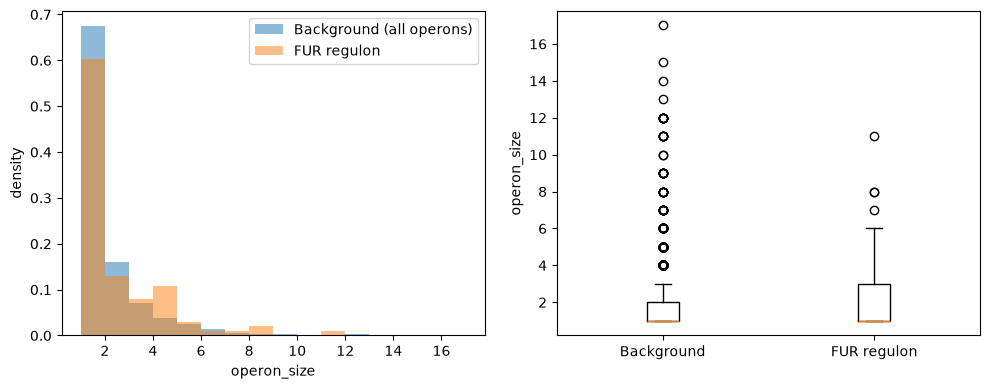

In [15]:
# Step 6
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(bg_sizes, bins=range(1, 18), alpha=0.5, density=True, label="Background (all operons)")
axes[0].hist(fur_sizes, bins=range(1, 18), alpha=0.5, density=True, label="FUR regulon")
axes[0].set_xlabel("operon_size")
axes[0].set_ylabel("density")
axes[0].legend()

axes[1].boxplot([bg_sizes, fur_sizes], tick_labels=["Background", "FUR regulon"])
axes[1].set_ylabel("operon_size")

plt.tight_layout()
plt.show()

> **Answer**
>
> *What did this step produce? Any issues?*
>
> 이전 코드의 통계 검정 결과를 시각화하는 단계이다. 왼쪽 그래프는 두 집단의 density 히스토그램이다. 전체 데이터의 개수가 배경군이 압도적으로 크므로 개수 대신 density=True 옵션으로 상대 비율로 비교했다. 오른쪽 그래프는 박스플롯이다.

In [16]:
# Step 3.5-1: unmapped TU 중 "root+대문자 subunit 문자들" 형태(fusion 이름)를
# 개별 유전자로 분해해서 RegulonDB gene_to_size와 재매칭 시도.
def decompose_fusion_name(tu_name):
    base = tu_name.split("_")[0]  # ygaQ_2 같은 접미사(중복 TU 구분용) 제거
    m = re.match(r"^([a-z]+)([A-Z]{2,})$", base)  # 소문자 root + 대문자 2개 이상 패턴(예: sdhCDAB)
    if m:
        root, letters = m.groups()
        return [root + letter for letter in letters]  # sdh+C, sdh+D, sdh+A, sdh+B 로 개별 유전자명 생성
    # fusion 패턴이 아니면(예: qor), 같은 root로 시작하는 후보 유전자(예: qorA, qorB) 탐색
    return [g for g in gene_to_size if g.startswith(base) and len(g) <= len(base) + 1] or [base]

resolved_sizes, ambiguous_tus, still_missing_tus = {}, [], []
for tu in unmapped_tus:
    genes = decompose_fusion_name(tu)
    sizes_found = {gene_to_size[g] for g in genes if g in gene_to_size}  # 분해된 유전자들이 속한 오페론 크기 집합
    if len(sizes_found) == 1:
        resolved_sizes[tu] = sizes_found.pop()      # 크기가 하나로 모이면 확정
    elif len(sizes_found) > 1:
        ambiguous_tus.append(tu)                    # 서로 다른 크기의 오페론에 걸쳐 있으면 판단 보류
    else:
        still_missing_tus.append(tu)                # RegulonDB에서 전혀 못 찾으면 결측 처리

print(f"[Step 3.5] 새로 크기 확정된 TU: {resolved_sizes}")
print(f"[Step 3.5] 판단 보류(애매): {ambiguous_tus}")
print(f"[Step 3.5] 여전히 RegulonDB에 없음: {still_missing_tus}")

[Step 3.5] 새로 크기 확정된 TU: {'entCEBAH': 5, 'sdhCDAB': 10, 'yfcUTSRQPO': 6, 'ygaQ_2': 1, 'insJK': 1, 'qor': 1, 'yjhIH': 3}
[Step 3.5] 판단 보류(애매): ['efeUOB']
[Step 3.5] 여전히 RegulonDB에 없음: ['ycgG', 'ymgI', 'gmr', 'yoaD', 'yebN', 'yebS', 'yqjH', 'yhhK', 'yjdQ', 'yjgI']


[Step 3.5] 보정 전: n=101, U=143986.0, p=0.05244, 평균=2.079
[Step 3.5] 보정 후: n=108, U=156499.0, p=0.01716, 평균=2.194


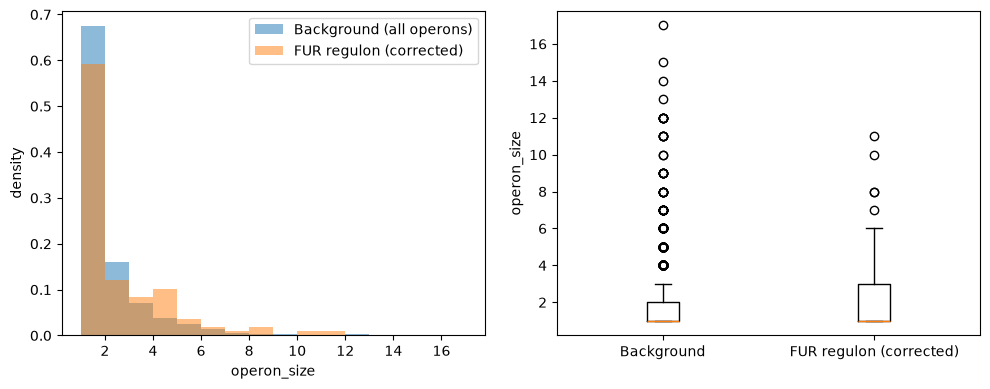

In [17]:
# Step 3.5-2: 새로 확정된 크기를 fur_sizes에 합쳐서 분포와 통계를 재계산
fur_sizes_corrected = fur_sizes + list(resolved_sizes.values())

stat_corrected, pvalue_corrected = mannwhitneyu(fur_sizes_corrected, bg_sizes, alternative="two-sided")
print(f"[Step 3.5] 보정 전: n={len(fur_sizes)}, U={stat}, p={pvalue:.4g}, 평균={pd.Series(fur_sizes).mean():.3f}")
print(f"[Step 3.5] 보정 후: n={len(fur_sizes_corrected)}, U={stat_corrected}, p={pvalue_corrected:.4g}, 평균={pd.Series(fur_sizes_corrected).mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(bg_sizes, bins=range(1, 18), alpha=0.5, density=True, label="Background (all operons)")
axes[0].hist(fur_sizes_corrected, bins=range(1, 18), alpha=0.5, density=True, label="FUR regulon (corrected)")
axes[0].set_xlabel("operon_size")
axes[0].set_ylabel("density")
axes[0].legend()

axes[1].boxplot([bg_sizes, fur_sizes_corrected], tick_labels=["Background", "FUR regulon (corrected)"])
axes[1].set_ylabel("operon_size")

plt.tight_layout()
plt.show()

> **Answer**
>
> *What did this step produce? Any issues?*
> 
>  Q1/중앙값/Q3/whisker 범위 자체는 보정 전후로 똑같다(1, 1, 2, 4). 그래서 박스와 whisker 모양은 그림상 거의 안 변한다. 차이는 전부 이상치(fliers) 쪽에 있다: 보정 후엔 5가 하나 더(4→5개), 6이 하나 더(3→4개), 결정적으로 9가 10으로 바뀌면서 극단값이 하나 더 커졌다. boxplot의 변화는 안 보이나 Mann-Whitney U test의 순위 합에는 반영돼서 p-value가 유의미하게 떨어진다.

*(Add more step cells as needed.)*

> **W5 D5 checkpoint:**
> - [ ] At least first 2 steps producing output
> - [ ] Any blockers documented in `/log`
> - [ ] `/log` run


---
## Part 5 — Results
**Target: W6 Days 1–3**

Document your results. Each figure needs a 1–2 sentence caption — what it shows and what you observe.


In [12]:
# Figure 1


> **Answer**
>
> **Figure 1:** [What this figure shows and what you observe]


In [13]:
# Figure 2 (add as needed)


> **Answer**
>
> **Figure 2:** [Caption]


> **W6 D3 checkpoint:**
> - [ ] All pipeline steps complete
> - [ ] At least one figure with a written caption
> - [ ] `/log` run


---
## Part 6 — Report
**Target: W6 Days 4–5**

Write your report in the cells below. This is **your own writing** — Claude may be consulted for phrasing, but the scientific content must be yours.


### Question
*(one sentence)*


> **Answer**
>
> [Your question here]


### Methods
*(tools, parameters, files used — enough to reproduce)*


> **Answer**
>
> [Your methods here]


### Results
*(what did you find? reference figures by number)*


> **Answer**
>
> [Your results here]


### Interpretation
*(what does this mean biologically? how does it compare to the known FUR regulon?)*


> **Answer**
>
> [Your interpretation here]


### Limitations
*(what would you do differently with more time?)*


> **Answer**
>
> [Your limitations here]


---
Run `/log` one last time, then submit this notebook as your deliverable.


## Git — Commit Your Work

Every session ends with a commit. Run the commands below in your terminal (not in this notebook).

Write your own commit message following the format: `feat(miniproject): <what you did>`.  
If you're unsure what to write, ask Claude Code to suggest one based on what you worked on.

In [14]:
# Run these in the terminal (not here):
# git add notebooks/
# git commit -m "..."   # write your own commit message; use Claude Code to help if needed
# git push
